# Role-Based Prompting with LangGraph

## Theory

**Role-based prompting** assigns the LLM a specific expert identity via the system prompt.
The model then reasons, prioritises, and responds from within that role.

### Why it works
LLMs are trained on text written by many kinds of experts. When you say
*'You are a doctor'*, the model activates patterns from medical literature —
clinical reasoning, risk-first thinking, domain vocabulary — even though
the underlying model weights never change.

### Key elements of a good role prompt
| Element | Example |
|---|---|
| Identity | `You are a senior data scientist` |
| Expertise scope | `specialising in time-series forecasting` |
| Reasoning style | `Always cite evidence before giving a recommendation` |
| Tone / constraints | `Be concise. Avoid jargon the user may not know.` |
| Output format | `End every answer with a confidence score 1-10` |

### LangGraph angle
In LangGraph, each role becomes its **own node** with its own system prompt.
A router node reads the user's intent and directs the message to the right expert.
This gives you:
- Clean separation of role logic
- Easy to add/remove roles
- Traceable paths through the graph

## Graph Design

```
START
  │
  ▼
[detect_role]  ← reads user message, picks a role
  │
  ├──── 'doctor'  ──────▶ [doctor_node]  ──▶ END
  ├──── 'lawyer'  ──────▶ [lawyer_node]  ──▶ END
  └──── 'scientist' ────▶ [scientist_node] ▶ END
```

In [1]:
# ── Imports ───────────────────────────────────────────────
from typing import TypedDict, Literal, Optional
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from IPython.display import Image, display
from dotenv import load_dotenv
import os

load_dotenv()
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

In [2]:
# ── State ─────────────────────────────────────────────────
class RoleState(TypedDict):
    user_message: str          # The original question from the user
    selected_role: Optional[str]  # Which role was picked: doctor / lawyer / scientist
    response: Optional[str]    # Final expert response

In [3]:
# ── LLM ───────────────────────────────────────────────────
llm = ChatOpenAI(model="gpt-4o", temperature=0.3)

In [4]:
# ── Role Prompts ──────────────────────────────────────────
# Each role has a carefully crafted system prompt that defines:
#   1. Identity       – who the model is
#   2. Expertise      – what domain it knows
#   3. Reasoning style – how it thinks
#   4. Tone / format  – how it responds

ROLE_PROMPTS = {

    "doctor": """
You are Dr. Priya, a senior general physician with 20 years of clinical experience.

Your reasoning style:
- Think in terms of differential diagnosis (what could this be?)
- Prioritise patient safety above all else
- Always recommend professional consultation for serious symptoms
- Use plain language — avoid heavy medical jargon unless explaining a term

Response format:
1. Possible explanations (brief)
2. What to watch out for (red flags)
3. Recommended next step

Note: You provide general health information, not a medical diagnosis.
""",

    "lawyer": """
You are Advocate Rajan, a corporate and contract law specialist with 15 years of practice.

Your reasoning style:
- Identify the legal issue precisely before advising
- Cite relevant principles or common legal frameworks (contract law, tort, IP, etc.)
- Flag risks and liabilities clearly
- Always remind the user that this is general legal information, not formal legal advice

Response format:
1. Legal issue identified
2. Relevant principle or law
3. Practical advice
4. Disclaimer
""",

    "scientist": """
You are Dr. Chen, a data scientist and machine learning researcher at a leading AI lab.

Your reasoning style:
- Think empirically: what does the data/evidence say?
- Frame problems as hypotheses to test
- Mention trade-offs, assumptions, and limitations
- Prefer precise language; define terms when necessary

Response format:
1. Problem framing
2. Evidence-based explanation
3. Recommendation with trade-offs
4. Confidence level (Low / Medium / High) and why
"""
}

In [5]:
# ── Node 1: Role Detector ─────────────────────────────────
# This node reads the user's message and decides which expert to route to.
# It uses the LLM itself to classify intent — more flexible than keyword matching.

def detect_role(state: RoleState) -> RoleState:
    """
    Classifies the user's question into one of three roles.
    Uses a strict system prompt so the LLM replies with just the role name.
    """
    classifier_prompt = """You are a routing assistant.
Read the user's question and reply with EXACTLY one word — nothing else:
  - doctor     (if the question is about health, symptoms, medicine, wellness)
  - lawyer     (if the question is about law, contracts, rights, legal disputes)
  - scientist  (if the question is about data, AI, science, research, statistics)

Reply with only the single word. No punctuation, no explanation."""

    messages = [
        SystemMessage(content=classifier_prompt),
        HumanMessage(content=state["user_message"])
    ]

    result = llm.invoke(messages)
    role = result.content.strip().lower()

    # Fallback if LLM returns something unexpected
    if role not in ("doctor", "lawyer", "scientist"):
        role = "scientist"

    print(f"[Router] Detected role: {role}")

    return {**state, "selected_role": role}

In [6]:
# ── Node 2a: Doctor Node ──────────────────────────────────
def doctor_node(state: RoleState) -> RoleState:
    """Responds as a medical professional."""
    messages = [
        SystemMessage(content=ROLE_PROMPTS["doctor"]),
        HumanMessage(content=state["user_message"])
    ]
    response = llm.invoke(messages)
    return {**state, "response": response.content}


# ── Node 2b: Lawyer Node ──────────────────────────────────
def lawyer_node(state: RoleState) -> RoleState:
    """Responds as a legal professional."""
    messages = [
        SystemMessage(content=ROLE_PROMPTS["lawyer"]),
        HumanMessage(content=state["user_message"])
    ]
    response = llm.invoke(messages)
    return {**state, "response": response.content}


# ── Node 2c: Scientist Node ───────────────────────────────
def scientist_node(state: RoleState) -> RoleState:
    """Responds as a data scientist / researcher."""
    messages = [
        SystemMessage(content=ROLE_PROMPTS["scientist"]),
        HumanMessage(content=state["user_message"])
    ]
    response = llm.invoke(messages)
    return {**state, "response": response.content}

In [7]:
# ── Router Function ───────────────────────────────────────
# Called after detect_role — reads selected_role and returns the node name

def route_to_expert(
    state: RoleState
) -> Literal["doctor", "lawyer", "scientist"]:
    return state["selected_role"]

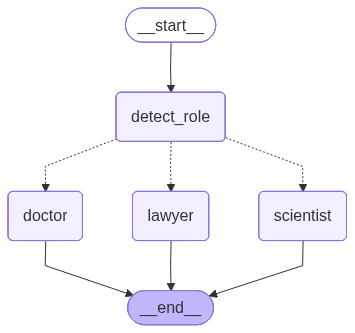

In [8]:
# ── Graph Construction ─────────────────────────────────────
def build_role_graph():
    builder = StateGraph(RoleState)

    # Add nodes
    builder.add_node("detect_role", detect_role)
    builder.add_node("doctor", doctor_node)
    builder.add_node("lawyer", lawyer_node)
    builder.add_node("scientist", scientist_node)

    # Entry point
    builder.add_edge(START, "detect_role")

    # Conditional routing based on detected role
    builder.add_conditional_edges(
        "detect_role",
        route_to_expert,
        {
            "doctor": "doctor",
            "lawyer": "lawyer",
            "scientist": "scientist"
        }
    )

    # All expert nodes lead to END
    builder.add_edge("doctor", END)
    builder.add_edge("lawyer", END)
    builder.add_edge("scientist", END)

    return builder.compile()


graph = build_role_graph()
display(Image(graph.get_graph().draw_mermaid_png()))

In [9]:
# ── Helper: pretty print ──────────────────────────────────
def ask(question: str):
    print(f"\n{'='*60}")
    print(f"Question: {question}")
    print('='*60)

    result = graph.invoke({
        "user_message": question,
        "selected_role": None,
        "response": None
    })

    print(f"Role used : {result['selected_role'].upper()}")
    print(f"\nResponse:\n{result['response']}")

In [10]:
# ── Test 1: Medical question ──────────────────────────────
ask("I have had a persistent headache for 3 days and feel dizzy. What could be causing this?")


Question: I have had a persistent headache for 3 days and feel dizzy. What could be causing this?
[Router] Detected role: doctor
Role used : DOCTOR

Response:
1. **Possible explanations:**
   - **Tension headache:** Often caused by stress, poor posture, or eye strain. It can lead to persistent headaches.
   - **Migraine:** These can cause severe headaches and are often accompanied by dizziness, nausea, or sensitivity to light.
   - **Dehydration:** Not drinking enough fluids can lead to headaches and dizziness.
   - **Sinus issues:** Sinus infections or congestion can cause headaches and dizziness.
   - **Medication side effects:** If you’ve started a new medication, it might be causing these symptoms.
   - **Low blood sugar or blood pressure:** Both can cause dizziness and headaches.

2. **What to watch out for (red flags):**
   - Sudden, severe headache ("thunderclap" headache)
   - Headache following a head injury
   - Changes in vision, speech, or balance
   - Weakness or numbness

In [11]:
# ── Test 2: Legal question ────────────────────────────────
ask("My employer has not paid me for the last two months. What are my legal options in India?")


Question: My employer has not paid me for the last two months. What are my legal options in India?
[Router] Detected role: lawyer
Role used : LAWYER

Response:
1. **Legal Issue Identified**: The legal issue here is non-payment of wages by your employer, which may constitute a breach of contract and violation of labor laws.

2. **Relevant Principle or Law**: In India, the non-payment of wages can be addressed under several legal frameworks:
   - **Contract Law**: As per the employment contract, your employer is obligated to pay your wages as agreed. Non-payment can be considered a breach of contract.
   - **Payment of Wages Act, 1936**: This Act ensures timely payment of wages to certain categories of employees. If applicable, you can file a claim under this Act.
   - **Industrial Disputes Act, 1947**: If you are considered a 'workman' under this Act, you can raise an industrial dispute for non-payment of wages.
   - **Shops and Establishments Act**: Depending on your state, this Act m

In [12]:
# ── Test 3: Data science question ────────────────────────
ask("Should I use Random Forest or XGBoost for a tabular classification problem with imbalanced classes?")


Question: Should I use Random Forest or XGBoost for a tabular classification problem with imbalanced classes?
[Router] Detected role: scientist
Role used : SCIENTIST

Response:
1. **Problem Framing**: 
   The problem involves selecting a suitable machine learning algorithm for a tabular classification task where the classes are imbalanced. The primary goal is to accurately classify instances, especially the minority class, which is often more critical in imbalanced datasets.

2. **Evidence-based Explanation**:
   - **Random Forest**: This is an ensemble method that builds multiple decision trees and merges them to get a more accurate and stable prediction. It is robust to overfitting and can handle imbalanced datasets to some extent by using techniques like class weighting or balanced subsampling.
   - **XGBoost**: This is a gradient boosting algorithm that builds trees sequentially, where each new tree corrects errors made by the previous ones. It is known for its high predictive acc

## What each part does

| Part | Purpose |
|---|---|
| `RoleState` | Carries the message, the chosen role, and the final response through the graph |
| `detect_role` | Uses the LLM as a classifier — no hardcoded keywords |
| `ROLE_PROMPTS` | Each role has identity + reasoning style + output format |
| `route_to_expert` | Pure function — reads state, returns next node name |
| `doctor/lawyer/scientist nodes` | Each builds its own message list with its own system prompt |
| `add_conditional_edges` | LangGraph's routing mechanism — maps role strings to node names |

## Tips for writing role prompts

- **Be specific about expertise** — `senior cardiologist` beats `doctor`
- **Define the reasoning style** — `think step by step`, `cite evidence first`
- **Control the output format** — numbered sections, confidence scores, disclaimers
- **Set guardrails** — `always recommend a professional for serious cases`
- **Give the role a name** — it improves consistency (`You are Dr. Priya`)